In [117]:
from pathlib import Path
from IPython.display import HTML

import numpy as np
import pandas as pd

zs = np.array([0.0, 0.2, 0.4, 0.6, 0.8, 0.9, 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99, 0.995, 0.999, 1.0], dtype=float)
one_link_latency_sec = 0.015107

common_thresholds = {
    "oneq_threshold": 0.999,
    "twoq_threshold": 0.9991,
    "meas_threshold": 0.996,
    "init_threshold": 0.99,
    "bell_threshold": 0.965,
    "t2_threshold_sec": 2.0,
}

thresholds = pd.DataFrame(
    [
        {"topology": "line_2", **common_thresholds},
        {"topology": "line_3", **common_thresholds},
        {"topology": "line_6", **common_thresholds},
    ]
)

rows = []
for _, threshold_row in thresholds.iterrows():
    for z in zs:
        idle_pz_threshold = (1.0 - np.exp(-one_link_latency_sec / threshold_row["t2_threshold_sec"])) / 2.0
        idle_pz = idle_pz_threshold * (1.0 - z)
        rows.append(
            {
                "topology": threshold_row["topology"],
                "z": z,
                "oneq": threshold_row["oneq_threshold"] + (1 - threshold_row["oneq_threshold"]) * z,
                "twoq": threshold_row["twoq_threshold"] + (1 - threshold_row["twoq_threshold"]) * z,
                "measurement": threshold_row["meas_threshold"] + (1 - threshold_row["meas_threshold"]) * z,
                "initialization": threshold_row["init_threshold"] + (1 - threshold_row["init_threshold"]) * z,
                "physical_bell_pair": threshold_row["bell_threshold"] + (1 - threshold_row["bell_threshold"]) * z,
                "idle_t2_sec": min(
                    -one_link_latency_sec / np.log(1.0 - 2.0 * idle_pz) if idle_pz > 0.0 else 199.99,
                    199.99,
                ),
            }
        )

z_table = pd.DataFrame(rows)
z_table = z_table.round(6)

runner_config_table = z_table.rename(
    columns={
        "oneq": "gate_fidelity",
        "twoq": "two_qubit_gate_fidelity",
        "measurement": "measurement_fidelity",
        "initialization": "initialization_fidelity",
        "physical_bell_pair": "physical_bell_pair_fidelity",
    }
)

config_output_path = Path("./config/generated_configs/z_plot_param_grid.json")
config_output_path.parent.mkdir(parents=True, exist_ok=True)
runner_config_table.to_json(config_output_path, orient="records", indent=2)

html_table = z_table.to_html(index=False, classes="raw-table")

display(
    HTML(
        f"""
        <style>
            .scroll-table {{
                max-height: 500px;
                overflow-y: auto;
                overflow-x: auto;
                border: 1px solid #ccc;
            }}
            .raw-table {{
                border-collapse: collapse;
                width: 100%;
            }}
            .raw-table th,
            .raw-table td {{
                padding: 6px 10px;
                border: 1px solid #ddd;
                text-align: left;
                white-space: nowrap;
            }}
            .raw-table th {{
                position: sticky;
                top: 0;
                background: white;
                z-index: 1;
            }}
        </style>
        <div class="scroll-table">
            {html_table}
        </div>
        """
    )
)


topology,z,oneq,twoq,measurement,initialization,physical_bell_pair,idle_t2_sec
line_2,0.000,0.999000,0.999100,0.996000,0.99000,0.965000,2.000000
line_2,0.200,0.999200,0.999280,0.996800,0.99200,0.972000,2.501893
line_2,0.400,0.999400,0.999460,0.997600,0.99400,0.979000,3.338379
line_2,0.600,0.999600,0.999640,0.998400,0.99600,0.986000,5.011350
line_2,0.800,0.999800,0.999820,0.999200,0.99800,0.993000,10.030260
line_2,0.900,0.999900,0.999910,0.999600,0.99900,0.996500,20.068076
line_2,0.910,0.999910,0.999919,0.999640,0.99910,0.996850,22.298701
line_2,0.920,0.999920,0.999928,0.999680,0.99920,0.997200,25.086983
line_2,0.930,0.999930,0.999937,0.999720,0.99930,0.997550,28.671917
line_2,0.940,0.999940,0.999946,0.999760,0.99940,0.997900,33.451829


In [118]:
processed_dir = Path("./log/runner_z_processed/z_param_grid")

grid_df = runner_config_table.rename(
    columns={
        "gate_fidelity": "gate",
        "two_qubit_gate_fidelity": "twoq",
        "measurement_fidelity": "meas",
        "initialization_fidelity": "prep",
        "physical_bell_pair_fidelity": "physbell",
        "idle_t2_sec": "T2",
    }
).copy()

key_columns = ["topology", "gate", "twoq", "meas", "prep", "T2", "physbell"]
grid_df[key_columns] = grid_df[key_columns].round(6)

rows = []
for path in sorted(processed_dir.iterdir()):
    if not path.is_file():
        continue

    latency_ps, fidelity_corrected, rows_processed = [
        part.strip() for part in path.read_text().strip().split(",")
    ]

    metadata = {}
    for chunk in path.name.split(","):
        if "=" not in chunk:
            continue
        key, value = chunk.split("=", 1)
        metadata[key] = value

    rows.append(
        {
            "topology": path.name.split("_2G,", 1)[0],
            "gate": round(float(metadata["gate"]), 6),
            "twoq": round(float(metadata["twoq"]), 6),
            "meas": round(float(metadata["meas"]), 6),
            "prep": round(float(metadata["prep"]), 6),
            "T2": round(float(metadata["T2"]), 6),
            "physbell": round(float(metadata["physbell"]), 6),
            "fidelity_corrected": float(fidelity_corrected),
            "rows_processed": int(rows_processed),
        }
    )

processed_df = pd.DataFrame(rows)
plot_df = processed_df.merge(grid_df[key_columns + ["z"]], on=key_columns, how="left")

summary_df = (
    plot_df.assign(
        weighted_fidelity=plot_df["fidelity_corrected"] * plot_df["rows_processed"]
    )
    .groupby(["topology", "z"], as_index=False)
    .agg(
        weighted_fidelity=("weighted_fidelity", "sum"),
        total_rows=("rows_processed", "sum"),
        run_count=("fidelity_corrected", "count"),
    )
    .sort_values(["topology", "z"])
)

summary_df["fidelity_mean"] = (
    summary_df["weighted_fidelity"] / summary_df["total_rows"]
)

display(summary_df.round({"z": 6, "fidelity_mean": 6}))


,topology,z,weighted_fidelity,total_rows,run_count,fidelity_mean
0,line_2,0.000,47749.0,50000,5,0.95498
1,line_2,0.200,48489.0,50000,5,0.96978
2,line_2,0.400,49174.0,50000,5,0.98348
3,line_2,0.600,49565.0,50000,5,0.99130
4,line_2,0.800,49901.0,50000,5,0.99802
5,line_2,0.900,49971.0,50000,5,0.99942
6,line_2,0.910,49977.0,50000,5,0.99954
7,line_2,0.920,49987.0,50000,5,0.99974
8,line_2,0.930,49978.0,50000,5,0.99956
9,line_2,0.940,49988.0,50000,5,0.99976


   topology      z  weighted_fidelity  total_rows  run_count  fidelity_mean
0    line_2  0.000            47749.0       50000          5        0.95498
1    line_2  0.200            48489.0       50000          5        0.96978
2    line_2  0.400            49174.0       50000          5        0.98348
3    line_2  0.600            49565.0       50000          5        0.99130
4    line_2  0.800            49901.0       50000          5        0.99802
5    line_2  0.900            49971.0       50000          5        0.99942
6    line_2  0.910            49977.0       50000          5        0.99954
7    line_2  0.920            49987.0       50000          5        0.99974
8    line_2  0.930            49978.0       50000          5        0.99956
9    line_2  0.940            49988.0       50000          5        0.99976
10   line_2  0.950            49995.0       50000          5        0.99990
11   line_2  0.960            49997.0       50000          5        0.99994
12   line_2 

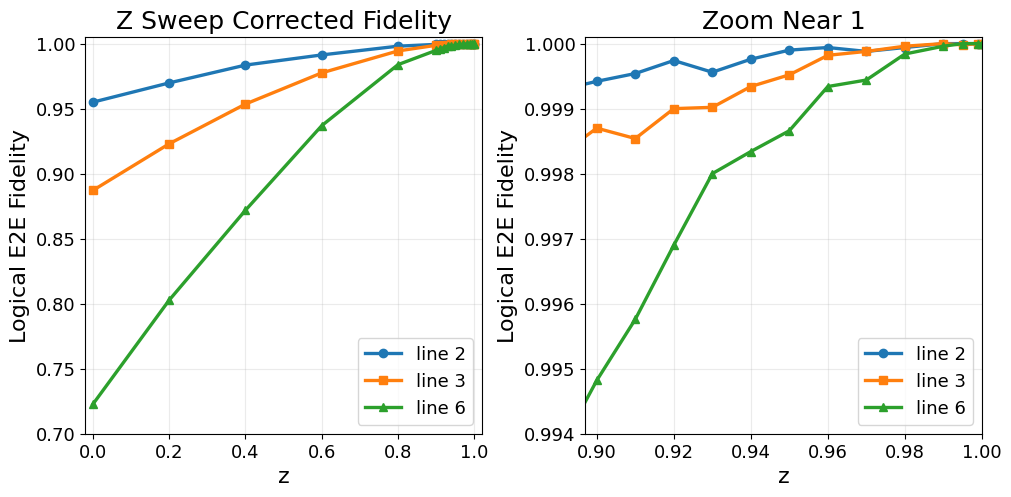

In [119]:
topology_colors = {
    "line_2": "tab:blue",
    "line_3": "tab:orange",
    "line_6": "tab:green",
}
topology_markers = {
    "line_2": "o",
    "line_3": "s",
    "line_6": "^",
}

title_fontsize = 18
label_fontsize = 16
tick_fontsize = 13
legend_fontsize = 13

fig, axes = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)
ax_full, ax_zoom = axes


for topology in ["line_2", "line_3", "line_6"]:
    topology_df = summary_df[summary_df["topology"] == topology].sort_values("z")
    print(f"{topology_df}")
    ax_full.plot(
        topology_df["z"],
        topology_df["fidelity_mean"],
        marker=topology_markers[topology],
        linewidth=2.4,
        markersize=6,
        color=topology_colors[topology],
        label=topology.replace("_", " "),
    )

    ax_zoom.plot(
        topology_df["z"],
        topology_df["fidelity_mean"],
        marker=topology_markers[topology],
        linewidth=2.4,
        markersize=6,
        color=topology_colors[topology],
        label=topology.replace("_", " "),
    )

ax_full.set_title("Z Sweep Corrected Fidelity", fontsize=title_fontsize)
ax_full.set_xlabel("z", fontsize=label_fontsize)
ax_full.set_ylabel("Logical E2E Fidelity", fontsize=label_fontsize)
ax_full.set_xlim(-0.02, 1.02)
ax_full.set_ylim(0.70, 1.005)
ax_full.grid(True, alpha=0.25)
ax_full.legend(loc="lower right", frameon=True, fontsize=legend_fontsize)
ax_full.tick_params(axis="both", labelsize=tick_fontsize)
ax_full.set_box_aspect(1)

ax_zoom.set_title("Zoom Near 1", fontsize=title_fontsize)
ax_zoom.set_xlabel("z", fontsize=label_fontsize)
ax_zoom.set_ylabel("Logical E2E Fidelity", fontsize=label_fontsize)
ax_zoom.set_xlim(0.897, 1.0)
ax_zoom.set_ylim(0.994, 1.0001)
ax_zoom.legend(loc="lower right", frameon=True, fontsize=legend_fontsize)
ax_zoom.grid(True, alpha=0.25)
ax_zoom.tick_params(axis="both", labelsize=tick_fontsize)
ax_zoom.set_box_aspect(1)

plt.show()


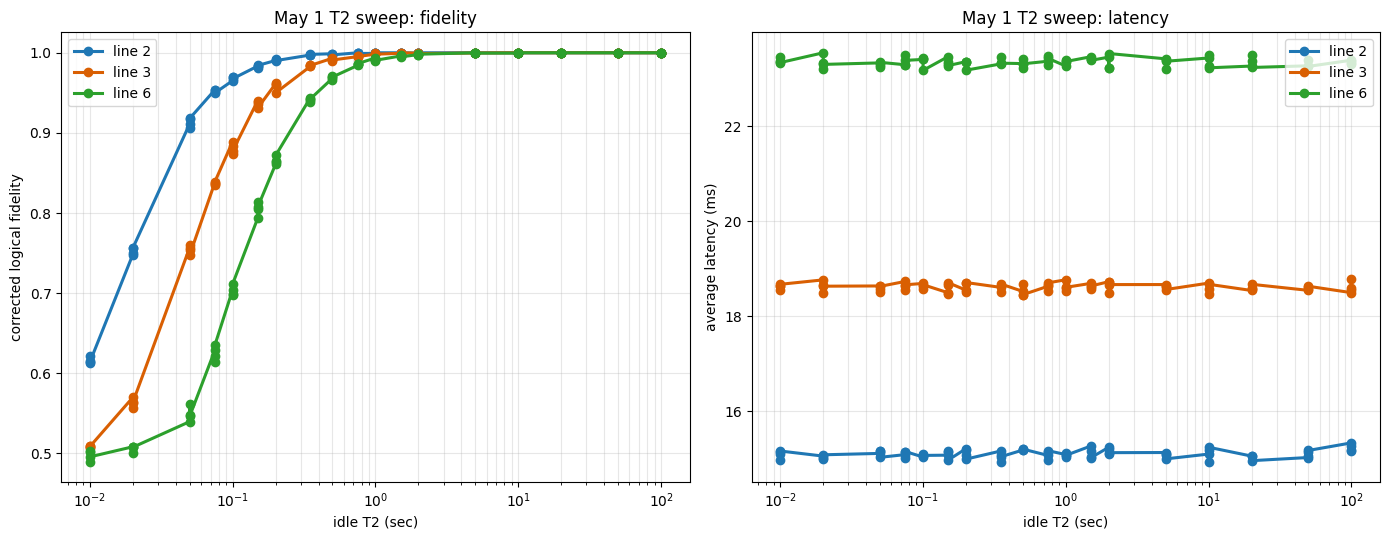

,topology,idle_t2_sec,fidelity_corrected,avg_latency_ps,run_count
0,line_2,0.01,0.6132,1.510265e+10,5000
1,line_2,0.01,0.6156,1.496897e+10,5000
2,line_2,0.01,0.6210,1.513634e+10,5000
3,line_2,0.01,0.6138,1.516436e+10,5000
4,line_2,0.02,0.7482,1.505744e+10,5000
...,...,...,...,...,...
209,line_6,50.00,1.0000,2.325681e+10,3960
210,line_6,100.00,1.0000,2.330220e+10,4024
211,line_6,100.00,1.0000,2.332663e+10,4170
212,line_6,100.00,1.0000,2.338737e+10,3638


In [120]:
from pathlib import Path

import matplotlib.pyplot as plt

processed_dir = Path("./log/runner_May1st_processed/t2_sweep")

rows = []
for path in sorted(processed_dir.iterdir()):
    if not path.is_file():
        continue

    latency_ps, fidelity_corrected, rows_processed = [
        part.strip() for part in path.read_text().strip().split(",")
    ]

    metadata = {}
    for chunk in path.name.split(","):
        if "=" not in chunk:
            continue
        key, value = chunk.split("=", 1)
        metadata[key] = value

    rows.append(
        {
            "topology": path.name.split("_2G,", 1)[0],
            "idle_t2_sec": float(metadata["T2"]),
            "idle_t1_sec": float(metadata["T1"]),
            "fidelity_corrected": float(fidelity_corrected),
            "avg_latency_ps": float(latency_ps),
            "run_count": int(rows_processed),
        }
    )

t2_df = pd.DataFrame(rows).sort_values(["topology", "idle_t2_sec"]).reset_index(drop=True)

topologies = ["line_2", "line_3", "line_6"]
colors = {
    "line_2": "#1f77b4",
    "line_3": "#d95f02",
    "line_6": "#2ca02c",
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
ax_fidelity, ax_latency = axes

for topology in topologies:
    topology_df = t2_df[t2_df["topology"] == topology].sort_values("idle_t2_sec")

    ax_fidelity.semilogx(
        topology_df["idle_t2_sec"],
        topology_df["fidelity_corrected"],
        marker="o",
        markersize=6,
        linewidth=2.2,
        color=colors[topology],
        label=topology.replace("_", " "),
    )

    ax_latency.semilogx(
        topology_df["idle_t2_sec"],
        topology_df["avg_latency_ps"] * 1e-9,
        marker="o",
        markersize=6,
        linewidth=2.2,
        color=colors[topology],
        label=topology.replace("_", " "),
    )

ax_fidelity.set_xlabel("idle T2 (sec)")
ax_fidelity.set_ylabel("corrected logical fidelity")
ax_fidelity.set_title("May 1 T2 sweep: fidelity")
ax_fidelity.grid(True, alpha=0.3, which="both")
ax_fidelity.legend()

ax_latency.set_xlabel("idle T2 (sec)")
ax_latency.set_ylabel("average latency (ms)")
ax_latency.set_title("May 1 T2 sweep: latency")
ax_latency.grid(True, alpha=0.3, which="both")
ax_latency.legend()

plt.tight_layout()
plt.show()

display(
    t2_df[["topology", "idle_t2_sec", "fidelity_corrected", "avg_latency_ps", "run_count"]].round(
        {
            "idle_t2_sec": 3,
            "fidelity_corrected": 6,
            "avg_latency_ps": 2,
        }
    )
)


nodes,2,3,6
z,,,
0.000,0.95498,0.88712,0.72272
0.200,0.96978,0.92296,0.80272
0.400,0.98348,0.95352,0.87184
0.600,0.99130,0.97750,0.93688
0.800,0.99802,0.99436,0.98382
0.900,0.99942,0.99870,0.99482
0.910,0.99954,0.99854,0.99576
0.920,0.99974,0.99900,0.99690
0.930,0.99956,0.99902,0.99800


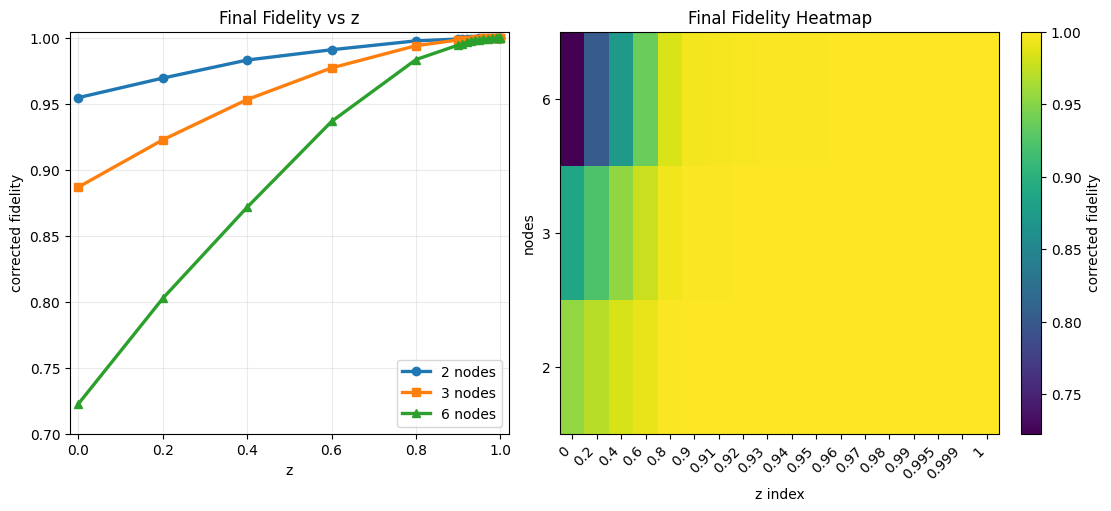

In [121]:
analysis_df = summary_df.copy()
analysis_df["nodes"] = analysis_df["topology"].str.extract(r"line_(\d+)").astype(int)
analysis_df = analysis_df.sort_values(["nodes", "z"])

pivot_df = analysis_df.pivot(index="z", columns="nodes", values="fidelity_mean")

display(pivot_df.round(6))

fig, axes = plt.subplots(1, 2, figsize=(11, 5), constrained_layout=True)
ax_lines, ax_heatmap = axes

node_colors = {
    2: "tab:blue",
    3: "tab:orange",
    6: "tab:green",
}
node_markers = {
    2: "o",
    3: "s",
    6: "^",
}

for nodes in sorted(analysis_df["nodes"].unique()):
    d = analysis_df[analysis_df["nodes"] == nodes].sort_values("z")
    ax_lines.plot(
        d["z"],
        d["fidelity_mean"],
        color=node_colors[nodes],
        marker=node_markers[nodes],
        linewidth=2.4,
        markersize=6,
        label=f"{nodes} nodes",
    )

ax_lines.set_title("Final Fidelity vs z")
ax_lines.set_xlabel("z")
ax_lines.set_ylabel("corrected fidelity")
ax_lines.set_xlim(-0.02, 1.02)
ax_lines.set_ylim(0.70, 1.005)
ax_lines.grid(True, alpha=0.25)
ax_lines.legend(frameon=True)

im = ax_heatmap.imshow(
    pivot_df.T,
    aspect="auto",
    origin="lower",
    cmap="viridis",
    vmin=pivot_df.min().min(),
    vmax=1.0,
)

ax_heatmap.set_title("Final Fidelity Heatmap")
ax_heatmap.set_xlabel("z index")
ax_heatmap.set_ylabel("nodes")
ax_heatmap.set_yticks(range(len(pivot_df.columns)))
ax_heatmap.set_yticklabels(pivot_df.columns.tolist())
ax_heatmap.set_xticks(range(len(pivot_df.index)))
ax_heatmap.set_xticklabels(
    [f"{z:.3f}".rstrip("0").rstrip(".") for z in pivot_df.index],
    rotation=45,
    ha="right",
)

fig.colorbar(im, ax=ax_heatmap, label="corrected fidelity")
plt.show()


In [122]:
analysis_df = summary_df.copy()
analysis_df["nodes"] = analysis_df["topology"].str.extract(r"line_(\d+)").astype(int)
analysis_df = analysis_df.sort_values(["nodes", "z"])

def z_for_target_fidelity(z_values, fidelity_values, target_fidelity):
    z_values = np.asarray(z_values, dtype=float)
    fidelity_values = np.asarray(fidelity_values, dtype=float)

    fidelity_values = np.maximum.accumulate(fidelity_values)

    if target_fidelity < fidelity_values[0] or target_fidelity > fidelity_values[-1]:
        return np.nan

    return float(np.interp(target_fidelity, fidelity_values, z_values))

targets = [0.99, 0.995, 0.999, 0.9995]

rows = []
for nodes in sorted(analysis_df["nodes"].unique()):
    d = analysis_df[analysis_df["nodes"] == nodes].sort_values("z")
    for target in targets:
        rows.append(
            {
                "nodes": nodes,
                "target_fidelity": target,
                "z_needed": z_for_target_fidelity(
                    d["z"],
                    d["fidelity_mean"],
                    target,
                ),
            }
        )

z_needed_df = pd.DataFrame(rows)
display(
    z_needed_df.pivot(index="target_fidelity", columns="nodes", values="z_needed").round(6)
)


nodes,2,3,6
target_fidelity,,,
0.9900,0.566752,0.748280,0.856182
0.9950,0.710119,0.814747,0.901915
0.9990,0.870000,0.920000,0.955000
0.9995,0.906667,0.948889,0.971500


In [123]:
def fit_residual_power_law(z_needed_df, target_fidelity):
    d = z_needed_df[z_needed_df["target_fidelity"] == target_fidelity].sort_values("nodes")
    nodes = d["nodes"].to_numpy(dtype=float)
    residual = 1.0 - d["z_needed"].to_numpy(dtype=float)

    coeffs = np.polyfit(np.log(nodes), np.log(residual), 1)
    k = coeffs[0]
    log_c = coeffs[1]
    c = np.exp(log_c)
    return c, k

def estimate_z_for_nodes(target_fidelity, target_nodes):
    c, k = fit_residual_power_law(z_needed_df, target_fidelity)
    residual = c * (target_nodes ** k)
    return 1.0 - residual

targets = [0.99, 0.995, 0.999, 0.9995]
estimate_nodes = [4, 5, 8, 10]

rows = []
for target in targets:
    for n in estimate_nodes:
        rows.append(
            {
                "target_fidelity": target,
                "nodes": n,
                "z_needed_estimate": estimate_z_for_nodes(target, n),
            }
        )

z_extrap_df = pd.DataFrame(rows)
display(
    z_extrap_df.pivot(index="target_fidelity", columns="nodes", values="z_needed_estimate").round(6)
)


nodes,4,5,8,10
target_fidelity,,,,
0.9900,0.792680,0.833500,0.895086,0.915743
0.9950,0.855791,0.884090,0.926835,0.941193
0.9990,0.935306,0.947676,0.966536,0.972935
0.9995,0.957993,0.966799,0.979772,0.984012


In [129]:
def z_needed(target_fidelity, nodes):
    eps = 1.0 - target_fidelity
    return 1.0 - 7.83 * (eps ** 0.497) * (nodes ** (-0.852 + 0.0239 * np.log(eps)))

equation_targets = [0.96, 0.995, 0.999, 0.9995]
equation_nodes = [2, 3, 4, 5, 6, 8, 10, 100]

rows = []
for target in equation_targets:
    for nodes in equation_nodes:
        rows.append(
            {
                "target_fidelity": target,
                "nodes": nodes,
                "z_needed_equation": z_needed(target, nodes),
            }
        )

z_equation_df = pd.DataFrame(rows)
display(
    z_equation_df.pivot(index="target_fidelity", columns="nodes", values="z_needed_equation").round(6)
)


nodes,2,3,4,5,6,8,10,100
target_fidelity,,,,,,,,
0.9600,0.169481,0.430134,0.563772,0.645439,0.700679,0.770873,0.813768,0.978066
0.9950,0.714535,0.808034,0.855137,0.883556,0.902585,0.926488,0.940909,0.993793
0.9990,0.875093,0.917304,0.938282,0.950814,0.959139,0.969505,0.975697,0.997663
0.9995,0.912504,0.942460,0.957261,0.966065,0.971894,0.979123,0.983424,0.998466
